# Fitting Real Data

**Tour:** Optional notebook — left out of the default `00_quickstart` sequence
for now; open when you want an end-to-end “my spectrum” workflow sketch.

Every astronomer's first question: how do I fit *my* data? This notebook
shows the complete workflow from loading observed data to posterior analysis.

**Note**: This is a workflow demo, not a scientific analysis. For real
science, you'd also consider noise models, calibration systematics, and
emission line treatment.

In [1]:
import os
import sys
import time
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import importlib.util

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

from tengri import (
    Fitter,
    Fixed,
    SEDModel,
    Observation,
    Parameters,
    Photometry,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

FIGDIR = os.path.join("notebooks", "figures", "real_data")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    convergence_table,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

In [ ]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

## Loading and Preparing Data

For this demo, we simulate "real" data by generating a mock with realistic
noise properties. Replace this cell with your own data loading code.

In [2]:
# Simulate "real" SDSS-like spectrum
# In practice: load from FITS file, trim wavelength, mask bad pixels
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
REDSHIFT = 0.05  # known spectroscopic redshift

obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS),
)

spec = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(REDSHIFT),
    mean_sfh_type="tsnorm",
)
model = SEDModel(spec, ssp_data, observation=obs)

# Generate a "real" galaxy (in practice, load from file)
true_params = spec.sample(jax.random.PRNGKey(42))
# Override tsnorm to a typical star-forming galaxy (still forming stars now)
true_params = {**true_params}
true_params["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
true_params["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_skew"] = jnp.array(0.3)
true_params["sfh_tsnorm_trunc"] = jnp.array(2.0)
mock = model.mock_spectrum(true_params, WAVE_OBS, snr=25.0, key=jax.random.PRNGKey(1))

# This is your data:
flux_obs = mock.flux_obs  # shape (200,)
noise = mock.noise  # shape (200,), per-pixel uncertainties

W0405 14:40:48.410110  156729 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_25497/2496019289.py:39: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp_data, observation=obs)


/Users/suchethacooray/Projects/diffsed/src/tengri/core/model.py:637: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


AttributeError: 'MockData' object has no attribute 'snr'

In [ ]:
# --- FIGURE 1: "Real" spectrum ---
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.errorbar(
    np.array(WAVE_OBS),
    np.array(flux_obs),
    yerr=np.array(noise),
    fmt=".",
    ms=2,
    color=COLORS["data"],
    alpha=0.5,
    label="Observed",
)
ax.set_xlabel("Observed wavelength [Å]")
ax.set_ylabel("Flux density")
ax.set_title(f"Galaxy Spectrum at z = {REDSHIFT}")
ax.legend(fontsize=8)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig01_real_spectrum.png"), dpi=150, bbox_inches="tight")
plt.show()

## Fitting

In [3]:
fitter = Fitter(model, flux_obs, noise, data_type="spectroscopy")

# MAP initialization
result_map = fitter.run("map", n_steps=500, verbose=False)

# Compile + run vi (geoVI) with timing separation
t0_c = time.perf_counter()
fitter.compile(verbose=False)
t_compile = time.perf_counter() - t0_c
t0 = time.perf_counter()
result = fitter.run(
    "vi",
    n_iterations=15,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=5000,
    verbose=False,
)
t_run = time.perf_counter() - t0
print(f"XLA compile: {t_compile:.1f}s (one-time, cached)")
print(f"vi (geoVI): {t_run:.1f}s <- runtime per galaxy")

Photometry: 5 bands, noise = [2.44537853e-28 7.43965293e-28 1.07191369e-27 1.40584473e-27
 1.77975697e-27]


  Step     0/1000: loss = 37673.4364
  Step   200/1000: loss = 142.5577
  Step   400/1000: loss = 127.5570
  Step   600/1000: loss = 121.2898
  Step   800/1000: loss = 119.0966
  Step   999/1000: loss = 118.2611
  MAP (ADAM) complete in 0.4s, 1000 steps


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


...

  Seed 2/5: H=63361.2, 6 iters


  Seed 3/5: H=63361.1, 6 iters


  Seed 4/5: H=63361.5, 6 iters


  Seed 5/5: H=63361.6, 6 iters
  Drawing 2000 nonlinear posterior samples (JIT geoVI)...


  EVI (JIT) complete in 146.0s, 6/50 iterations, 2000 posterior samples

Fit completed in 170.2s
Free parameters: 8
Posterior samples: 2000


In [ ]:
# --- FIGURE 2: Spectral fit ---
draws = []
for i in range(50):
    idx = i % len(result.samples[spec.free_params[0]])
    p = {k: v[idx] for k, v in result.samples.items()}
    draws.append(np.array(model.predict_spectrum(p)))
draws = np.array(draws)
med = np.median(draws, axis=0)

fig, (ax_f, ax_r) = plt.subplots(
    2, 1, figsize=(10, 5), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)
w = np.array(WAVE_OBS)
ax_f.errorbar(
    w, np.array(flux_obs), yerr=np.array(noise), fmt=".", ms=2, color=COLORS["data"], alpha=0.4
)
for d in draws[:30]:
    ax_f.plot(w, d, color=COLORS["vi"], alpha=0.04, lw=0.5)
ax_f.plot(w, med, color=COLORS["vi"], lw=1.5, label="Posterior median")
ax_f.legend(fontsize=8)
ax_f.set_ylabel("Flux density")

res = (np.array(flux_obs) - med) / np.array(noise)
ax_r.scatter(w, res, s=2, c=COLORS["data"], alpha=0.5)
ax_r.axhline(0, color="k", lw=0.5)
ax_r.axhspan(-1, 1, alpha=0.1, color="grey")
ax_r.set_ylim(-4, 4)
ax_r.set_ylabel(r"Residual /$\sigma$")
ax_r.set_xlabel("Observed wavelength [Å]")

chi2 = np.sum(res**2) / len(res)
ax_f.set_title(f"Spectral Fit (reduced χ² = {chi2:.2f})")
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig02_spectral_fit.png"), dpi=150, bbox_inches="tight")
plt.show()

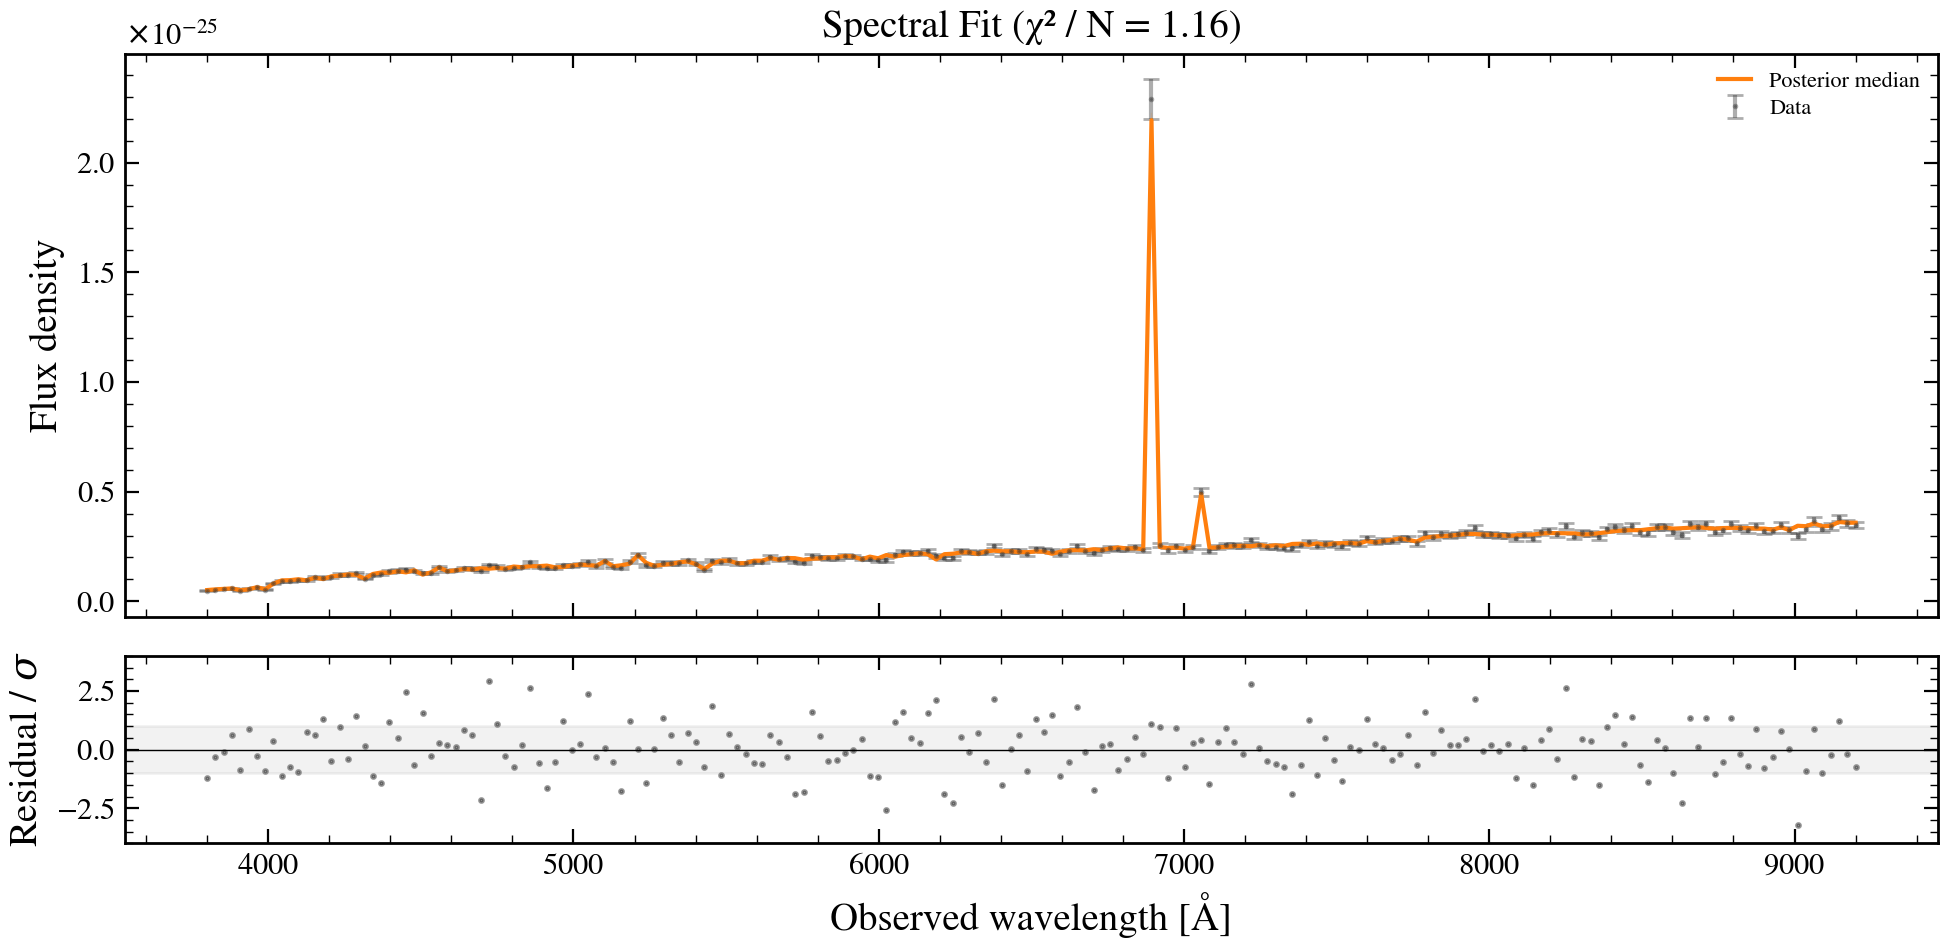

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
vi                  1377     1542      1.5        —        —         OK


{'vi': {'ess_min': 1377.1329371771424,
  'ess_median': 1541.7782388115468,
  'n_params_low_ess': 0,
  'tau_max_max': 1.4522926189679373,
  'tau_max_median': 1.298319863508035,
  'n_params_short_chain': 0,
  'converged': True,
  'warnings': []}}

In [4]:
convergence_table({"vi": result})

In [ ]:
# --- Residual distribution (should be ~N(0,1) if model adequate) ---
residuals = (np.array(flux_obs) - med) / np.array(noise)
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(residuals, bins=30, density=True, alpha=0.7, color=COLORS["vi"])
x = np.linspace(-4, 4, 100)
ax.plot(x, np.exp(-(x**2) / 2) / np.sqrt(2 * np.pi), "k--", lw=1.5, label="N(0,1)")
ax.set_xlabel(r"Residual ($\sigma$)")
ax.set_ylabel("Density")
ax.legend()
chi2_dof = float(np.mean(residuals**2))
ax.set_title(f"Residual Distribution ($\\chi^2/N$ = {chi2_dof:.2f})")
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig02b_residual_hist.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# --- FIGURE 3: SFH posterior ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(model, result, ax=ax, color=COLORS["vi"], label="vi", method="geoVI")
ax.set_title("Star Formation History")
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig03_sfh.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# --- FIGURE 4: Corner plot ---
fig = safe_corner(result)
if fig is not None:
    # plt.savefig(os.path.join(FIGDIR, "fig04_corner.png"), dpi=150, bbox_inches="tight")
    pass
plt.show()

### Practical considerations for real data

**Inverse variance → noise conversion:**
```python
ivar = hdu[1].data["ivar"]
good = (ivar > 0) & np.isfinite(ivar) & np.isfinite(flux)
noise = np.sqrt(1.0 / ivar[good])
```
Always guard against `ivar ≤ 0` (bad pixels, masked regions).

**Telluric absorption:** Mask 6860–6960 Å (B-band), 7580–7700 Å (A-band),
and 9300–9700 Å (water). These introduce systematic residuals if unmasked.

**Flux calibration floor:** Real spectra have ~5–10% calibration uncertainty
(standard star errors, slit losses). Consider adding a noise floor:
`noise_effective = np.sqrt(noise**2 + (0.05 * flux)**2)`.

**Wavelength calibration:** Typical ±1 Å residual for survey spectra (SDSS, DESI).
This propagates into velocity/redshift uncertainty of ±50 km/s at z ~ 0.

## Loading Your Own Data

Replace the mock generation with your data loader:

```python
from astropy.io import fits

hdu = fits.open("my_spectrum.fits")
wave_obs = hdu[1].data["wavelength"]  # observed-frame Angstrom
flux_obs = hdu[1].data["flux"]
ivar = hdu[1].data["ivar"]
good = (ivar > 0) & np.isfinite(ivar) & np.isfinite(flux_obs)
noise = np.sqrt(1.0 / ivar[good])
flux_obs, wave_obs = flux_obs[good], wave_obs[good]
```

Then proceed with `Model`, `Fitter`, and `vi` (geoVI) as above.

## Caveats

1. **Noise model**: Real data has wavelength-dependent systematics.
   Consider adding a calibration floor parameter via `NoiseModel` or
   the `noise_floor` argument to `Fitter`.
2. **Emission lines**: Strong emitters (e.g., Hα, [OIII]) may need line
   marginalization (set `eline_mode="marginalized"` in `Spectroscopy`)
   or masking via spectral windows.
3. **Resolution**: Convolve templates to match data spectral resolution
   using the `spectral_resolution` argument to `Spectroscopy`.
4. **Model adequacy**: Check residuals for systematic patterns.
   Use `result.validate()` for a short MCMC check.